# Reference design 3 — Four-qubit multiplexed readout

A four-transmon chip with frequency-multiplexed dispersive readout: four resonators of stepped length share one coplanar-waveguide feedline — the standard readout architecture for small superconducting processors.

> **Reference design — attribution.** Adapted, with attribution, from the open-source [SQDMetal](https://github.com/sqdlab/SQDMetal) project (Apache-2.0) and its benchmark devices in D. Sommers, P. Pakkiam, Z. Degnan, C.-C. Chiu, D. Gautam, Y.-H. Chen, and A. Fedorov, *"Open-Source Highly Parallel Electromagnetic Simulations for Superconducting Circuits,"* [arXiv:2511.01220](https://arxiv.org/abs/2511.01220) (2025). Re-implemented here with stock Quantum Metal components.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt):
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

design = designs.DesignPlanar()
design.overwrite_enabled = True

09:27PM 23s INFO [_start_renderers]: Renderer=gmsh skipped: runtime dependency not installed (renderer_gmsh requires gmsh. Install with: pip install 'quantum-metal[mesh]' (or the legacy alias 'quantum-metal[fem]')).


In [3]:
def feed(a, ap, b, bp, name):
    """Auto-route a coplanar-waveguide feedline segment between two pins."""
    RoutePathfinder(
        design,
        name,
        options=dict(
            fillet="90um",
            pin_inputs=Dict(
                start_pin=Dict(component=a, pin=ap), end_pin=Dict(component=b, pin=bp)
            ),
        ),
    )


def readout(clt, q, name, length):
    """Meandered lambda/4 readout resonator: coupled-line tee -> qubit readout pad."""
    RouteMeander(
        design,
        name,
        options=dict(
            fillet="90um",
            total_length=length,
            lead=Dict(start_straight="100um", end_straight="100um"),
            pin_inputs=Dict(
                start_pin=Dict(component=clt, pin="second_end"),
                end_pin=Dict(component=q, pin="readout"),
            ),
        ),
    )

## 1. Four transmons + four readout tees

Four transmons in a row; above each, a coupled-line tee on a single shared feedline.

In [4]:
xs = [-4.5, -1.5, 1.5, 4.5]
for i, x in enumerate(xs, 1):
    TransmonPocket(
        design,
        f"Q{i}",
        options=dict(
            pos_x=f"{x}mm",
            pos_y="-1.8mm",
            pad_width="425um",
            pocket_height="650um",
            connection_pads=dict(readout=dict(loc_W=1, loc_H=1)),
        ),
    )
    CoupledLineTee(
        design,
        f"clt{i}",
        options=dict(
            pos_x=f"{x}mm",
            pos_y="1.8mm",
            coupling_length="350um",
            down_length="300um",
            fillet="90um",
            open_termination=False,
        ),
    )

## 2. One shared feedline through all four tees

In [5]:
LaunchpadWirebond(
    design, "LPin", options=dict(pos_x="-7.5mm", pos_y="1.8mm", orientation="0")
)
LaunchpadWirebond(
    design, "LPout", options=dict(pos_x="7.5mm", pos_y="1.8mm", orientation="180")
)
feed("LPin", "tie", "clt1", "prime_start", "f0")
for i in range(1, 4):
    feed(f"clt{i}", "prime_end", f"clt{i + 1}", "prime_start", f"f{i}")
feed("clt4", "prime_end", "LPout", "tie", "f4")

## 3. Four frequency-multiplexed readout resonators

Stepped lengths -> distinct readout frequencies on the one feedline.

In [6]:
for i, L in zip(range(1, 5), ["6.8mm", "7.0mm", "7.2mm", "7.4mm"]):
    readout(f"clt{i}", f"Q{i}", f"read{i}", L)

09:27PM 23s WARNING [check_lengths]: For path table, component=read1, key=trace has short segments that could cause issues with fillet. Values in (1-2)  are index(es) in shapely geometry.


09:27PM 23s WARNING [check_lengths]: For path table, component=read1, key=cut has short segments that could cause issues with fillet. Values in (1-2)  are index(es) in shapely geometry.


## 4. Visualize

## Next steps

- **Inspect** the design tree: `design.components.keys()` and `design.qgeometry.tables`.
- **Export GDS** for fabrication: `design.renderers.gds.export_to_gds('chip.gds')` (Quantum Metal uses the modern `gdstk` backend).
- **Simulate**: render to Ansys HFSS/Q3D (the validation gold standard) or to the open-source FEM path (Gmsh + Elmer today; AWS Palace on the roadmap) to extract eigenmodes, *Q*, and the capacitance matrix.
- **Tweak**: every dimension above is a parameter — change `total_length` to retune resonator frequencies, or `pos_x`/`pos_y` to relayout.

In [7]:
design.components.keys()

['Q1',
 'clt1',
 'Q2',
 'clt2',
 'Q3',
 'clt3',
 'Q4',
 'clt4',
 'LPin',
 'LPout',
 'f0',
 'f1',
 'f2',
 'f3',
 'f4',
 'read1',
 'read2',
 'read3',
 'read4']

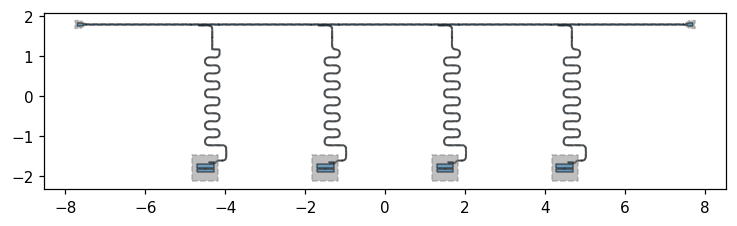

In [8]:
fig = qm.view(design)
qm.show_inline(fig)